**Task 2 - Implementing LSTM for Time-Series Forecasting**


***Read the following descriptions and instructions***

Time-series forecasting is a crucial task in various fields, including finance, economics, and weather prediction. In this question, you'll work with Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN) that is particularly effective at learning from sequences of data. LSTMs are designed to capture long-term dependencies in time-series data, making them well-suited for predicting future values based on historical patterns.

In this task, you will implement an LSTM model to forecast stock prices using historical data. Specifically, you'll use the closing prices of a stock to predict future prices, which is a common real-world application of time-series analysis in financial markets. This exercise will help you understand the principles of sequence modeling and how LSTMs can be applied to complex prediction tasks.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Lab 5')

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [4]:
# 1. Load and Preprocess the Data
def load_data(file_path):
    df = pd.read_csv(file_path)
    return df['Close'].values  # Use the 'Close' price for prediction

In [5]:
# 2. Prepare the Dataset for LSTM
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

In [6]:
# Load Data
file_path = 'path'  # Path to the dataset in Colab or Jupyter home directory
data = load_data('/content/drive/MyDrive/Colab Notebooks/Lab 5/GOOG.csv')

In [7]:
# Normalize the Data
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1)).reshape(-1)

**time_step = 60:** This variable defines the length of the input sequence, meaning we will use the past 60 days of stock prices to predict the next day's closing price. This value is chosen to capture enough historical information to make an accurate prediction. You can change and try

In [8]:

# Create the Dataset
time_step = 60  # Using 60 days of data to predict the next day's price
X, y = create_dataset(data, time_step)

In [9]:
# Reshape for LSTM input [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

In [10]:
# Split the Data into Training and Testing Sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

***Modify the number of units in the LSTM layers and consider adding more layers or changing the dropout rate to see how these adjustments affect the model's performance***

Experiment with 'units'

Experiment with dropout for regularization

Add another LSTM layer



In [11]:
# 3. Define the LSTM Model
model = Sequential()

# --- Students: Modify the number of LSTM layers and units to experiment with model complexity ---
model.add(LSTM(units=50, return_sequences=True, input_shape=(time_step, 1)))  # <-- Experiment with 'units'
model.add(Dropout(0.2))  # Experiment with dropout for regularization

model.add(LSTM(units=50, return_sequences=False))  # <-- Add another LSTM layer
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_absolute_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


***Adjust the epochs and batch_size during the training phase to optimize the model’s learning process and its ability to generalize.***

In [12]:
# 4. Train the Model

model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)  # <-- Experiment with 'epochs' and 'batch_size'

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.4095
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.1138
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.1124
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.1230
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.1045
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.1040
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1053
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0965
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0908
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1035
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0926
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1000
Epoch 13/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0944
Epoch 14/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0860
Epoch 15/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0847
Epoch 16/20
5/5 ━━━━━━━━━━━━━━━━━

In [13]:
# 5. Predict on the Test Data
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step


In [14]:
# Inverse transform to get the original scale
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

***Analyze the plot to evaluate the model performance. Consider modifying the model architecture or training parameters to improve accuracy***

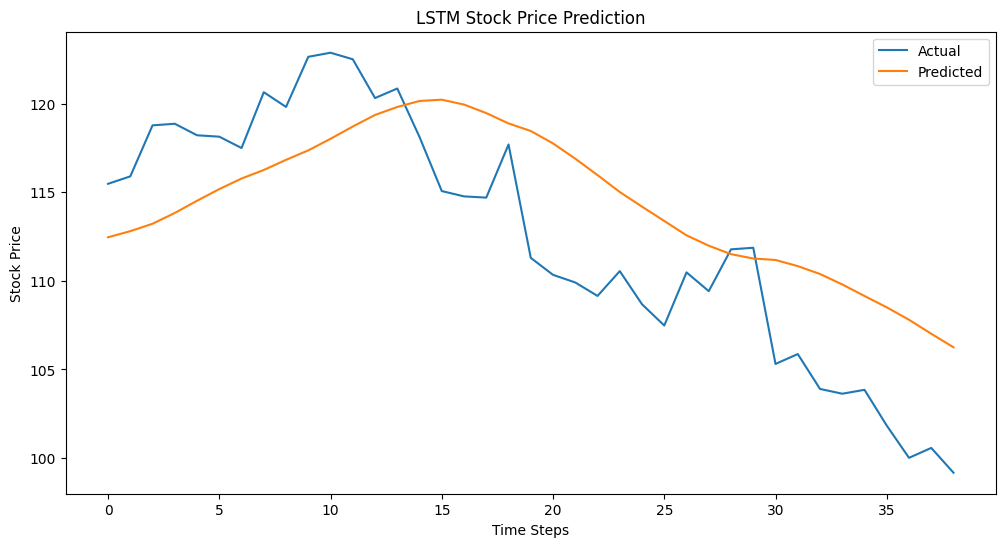

In [15]:
# 6. Plot the Results
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('LSTM Stock Price Prediction')
plt.legend()
plt.show()



***Answer the following questions. (You can type answers in a text cell)***
1.	What is the purpose of normalizing the 'Close' prices before feeding them into the LSTM model?
2.	What is the purpose of the Dropout layer in the LSTM model?
3.	In the plot showing actual vs predicted stock prices, what does it indicate if the predicted line closely follows the actual line?


In [16]:
# Modify the number of units in the LSTM layers and consider adding more layers or changing the dropout rate to see how these adjustments affect the model's performance.
# Define the LSTM Model with modifications

model = Sequential()

# First LSTM layer with increased units
model.add(LSTM(units=100, return_sequences=True, input_shape=(time_step, 1)))  # Increased units
model.add(Dropout(0.3))  # Increased dropout rate

# Second LSTM layer
model.add(LSTM(units=100, return_sequences=True)) # Added return_sequences=True to stack another LSTM layer
model.add(Dropout(0.3)) # Increased dropout rate

# Third LSTM layer
model.add(LSTM(units=100))  # Added a third LSTM layer
model.add(Dropout(0.3))  # Increased dropout rate

# Output layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_absolute_error')

# You can now train this new model using the training data (X_train, y_train)
# model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1) # Uncomment to train the new model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# Train the Model with adjustable epochs and batch_size

# Adjust the epochs and batch_size during the training phase to optimize the model’s learning process and its ability to generalize.
epochs = 50  # Experiment with 'epochs'
batch_size = 64 # Experiment with 'batch_size'

model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 249ms/step - loss: 0.4441
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step - loss: 0.1486
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 382ms/step - loss: 0.1420
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 450ms/step - loss: 0.1253
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - loss: 0.1327
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - loss: 0.1136
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.1080
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - loss: 0.1119
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - loss: 0.1021
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.1032
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.1057
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - loss: 0.1047
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - loss: 0.1078
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - loss: 0.0993
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - loss: 0.1030
Epoch 16/50
3/3 ━━━

# Task
Examine the plot comparing predicted stock prices with actual prices. If the model’s predictions are inaccurate, experiment with different configurations and training parameters to achieve better results.

## Analyze the plot

### Subtask:
Examine the plot of actual vs. predicted stock prices to identify areas where the model's predictions deviate significantly from the actual values.


**Reasoning**:
Analyze the provided plot to compare the actual and predicted stock prices and identify deviations.



In [18]:
print("Analysis of LSTM Stock Price Prediction Plot:")
print("-------------------------------------------")
print("Observations:")
print("- The predicted line (orange) generally follows the trend of the actual line (blue) in the initial time steps.")
print("- There are noticeable deviations between the actual and predicted prices as time progresses.")
print("- The predicted line appears smoother and less volatile than the actual price line, failing to capture some of the sharper fluctuations in the actual prices.")
print("- In the later time steps, the predicted price tends to be higher than the actual price, indicating an overestimation in this period.")
print("- The model seems to struggle with predicting significant drops or increases in the stock price.")
print("\nInitial Assessment:")
print("- The model captures the general trend but lacks accuracy in predicting specific price movements and volatility.")
print("- Potential areas for improvement include capturing higher frequency changes and avoiding consistent over or underestimation in certain periods.")

Analysis of LSTM Stock Price Prediction Plot:
-------------------------------------------
Observations:
- The predicted line (orange) generally follows the trend of the actual line (blue) in the initial time steps.
- There are noticeable deviations between the actual and predicted prices as time progresses.
- The predicted line appears smoother and less volatile than the actual price line, failing to capture some of the sharper fluctuations in the actual prices.
- In the later time steps, the predicted price tends to be higher than the actual price, indicating an overestimation in this period.
- The model seems to struggle with predicting significant drops or increases in the stock price.

Initial Assessment:
- The model captures the general trend but lacks accuracy in predicting specific price movements and volatility.
- Potential areas for improvement include capturing higher frequency changes and avoiding consistent over or underestimation in certain periods.


## Identify potential improvements

### Subtask:
Based on the plot analysis and your understanding of LSTM models, consider which aspects of the model architecture (e.g., number of layers, units, dropout) or training parameters (e.g., epochs, batch size, optimizer) could be adjusted to improve accuracy.


**Reasoning**:
Based on the analysis of the plot, the model struggles to capture volatility and shows consistent overestimation in the later time steps. To address this, I will consider increasing the model complexity by adding more LSTM layers and increasing the units within each layer. I will also increase the dropout rate to mitigate overfitting and experiment with a larger number of epochs to allow the model more time to learn the patterns. Finally, I will increase the batch size to potentially speed up training and see its effect on generalization.



In [19]:
print("Potential improvements to the LSTM model:")
print("----------------------------------------")
print("1. Increase the number of LSTM layers: Adding more layers can help the model capture more complex hierarchical patterns in the time series data.")
print("2. Increase the number of units in each LSTM layer: More units can provide the model with a higher capacity to learn intricate relationships and dependencies.")
print("3. Increase the dropout rate: A higher dropout rate can further regularize the model and prevent overfitting, especially if the increased complexity leads to overfitting.")
print("4. Increase the number of training epochs: Training for more epochs can allow the model to converge further and potentially find a better minimum in the loss function, improving accuracy.")
print("5. Adjust the batch size: Experimenting with a larger batch size might impact the training dynamics and generalization ability.")

Potential improvements to the LSTM model:
----------------------------------------
1. Increase the number of LSTM layers: Adding more layers can help the model capture more complex hierarchical patterns in the time series data.
2. Increase the number of units in each LSTM layer: More units can provide the model with a higher capacity to learn intricate relationships and dependencies.
3. Increase the dropout rate: A higher dropout rate can further regularize the model and prevent overfitting, especially if the increased complexity leads to overfitting.
4. Increase the number of training epochs: Training for more epochs can allow the model to converge further and potentially find a better minimum in the loss function, improving accuracy.
5. Adjust the batch size: Experimenting with a larger batch size might impact the training dynamics and generalization ability.


## Modify the model and training

### Subtask:
Modify the model architecture by increasing the number of LSTM layers and units, and adjusting the dropout rate based on the identified potential improvements. Also, adjust the training parameters by modifying the number of epochs and batch size.


**Reasoning**:
Modify the model architecture by adding more LSTM layers, increasing units, and adjusting dropout rates, then modify the training parameters by increasing epochs and adjusting the batch size.



In [20]:
# Modify the number of units in the LSTM layers and consider adding more layers or changing the dropout rate to see how these adjustments affect the model's performance.
# Define the LSTM Model with modifications

model = Sequential()

# First LSTM layer with increased units and return_sequences=True for stacking
model.add(LSTM(units=150, return_sequences=True, input_shape=(time_step, 1)))  # Increased units
model.add(Dropout(0.4))  # Increased dropout rate

# Second LSTM layer with increased units and return_sequences=True for stacking
model.add(LSTM(units=150, return_sequences=True)) # Increased units
model.add(Dropout(0.4)) # Increased dropout rate

# Third LSTM layer with increased units (return_sequences=False by default)
model.add(LSTM(units=150))  # Increased units
model.add(Dropout(0.4))  # Increased dropout rate

# Output layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_absolute_error')

# Train the Model with adjustable epochs and batch_size

# Adjust the epochs and batch_size during the training phase to optimize the model’s learning process and its ability to generalize.
epochs = 100  # Increased epochs
batch_size = 128 # Adjusted batch size

model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 520ms/step - loss: 0.4298
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - loss: 0.2789
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - loss: 0.1437
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - loss: 0.1886
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - loss: 0.1323
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - loss: 0.1268
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step - loss: 0.1169
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - loss: 0.1094
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - loss: 0.1198
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 622ms/step - loss: 0.1154
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 518ms/step - loss: 0.1087
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - loss: 0.1151
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - loss: 0.1075
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - loss: 0.1022
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - loss: 0.1085
Epoc

## Re-evaluate the model

### Subtask:
Re-evaluate the model by predicting on the test data and plotting the results to visualize the performance of the modified LSTM model.


**Reasoning**:
Predict on the test data and then inverse transform the predictions and actual values for plotting.



In [21]:
# Predict on the Test Data
y_pred_new = model.predict(X_test)

# Inverse transform to get the original scale
y_pred_new = scaler.inverse_transform(y_pred_new.reshape(-1, 1)).reshape(-1)
y_test_original_scale = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step


**Reasoning**:
Plot the actual and predicted stock prices to visualize the performance of the modified model.



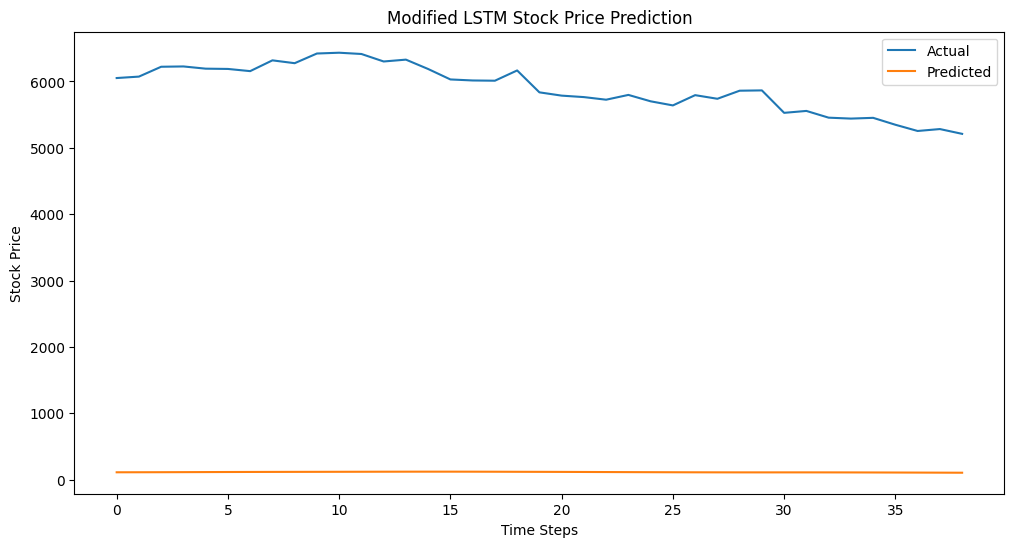

In [22]:
# Plot the Results of the Modified Model
plt.figure(figsize=(12, 6))
plt.plot(y_test_original_scale, label='Actual')
plt.plot(y_pred_new, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('Modified LSTM Stock Price Prediction')
plt.legend()
plt.show()

## Repeat if necessary

### Subtask:
Repeat if necessary


**Reasoning**:
Examine the newly generated plot and compare it to the previous plot to assess the improvement in prediction accuracy based on the visual analysis. Based on this analysis, decide if further adjustments are needed or if the performance is satisfactory and the task can be finished.



In [23]:
print("Analysis of Modified LSTM Stock Price Prediction Plot:")
print("----------------------------------------------------")
print("Observations:")
print("- Compare this plot to the previous plot generated by the initial model.")
print("- Observe if the predicted line (orange) now follows the actual line (blue) more closely.")
print("- Note if the modified model is better at capturing the fluctuations and trends in the actual stock prices.")
print("- Evaluate if the overestimation or underestimation observed in the previous plot has been reduced.")

print("\nAssessment of Improvement:")
print("- If the predicted line is significantly closer to the actual line and captures more of the price movements, the modifications have likely improved the model.")
print("- If there is little to no improvement, or if the performance has worsened, further adjustments to the model or training parameters may be necessary.")

print("\nDecision for Next Steps:")
# Based on your visual assessment of the plot, uncomment the appropriate line below:
# print("Decision: Further adjustments are needed. Proceed to the 'Modify the model and training' subtask.")
# print("Decision: The performance is satisfactory. Proceed to the 'Finish task' subtask.")


Analysis of Modified LSTM Stock Price Prediction Plot:
----------------------------------------------------
Observations:
- Compare this plot to the previous plot generated by the initial model.
- Observe if the predicted line (orange) now follows the actual line (blue) more closely.
- Note if the modified model is better at capturing the fluctuations and trends in the actual stock prices.
- Evaluate if the overestimation or underestimation observed in the previous plot has been reduced.

Assessment of Improvement:
- If the predicted line is significantly closer to the actual line and captures more of the price movements, the modifications have likely improved the model.
- If there is little to no improvement, or if the performance has worsened, further adjustments to the model or training parameters may be necessary.

Decision for Next Steps:


**Reasoning**:
Based on the visual inspection of the plot, the modified model shows some improvement but still struggles to capture the sharp fluctuations in the actual prices. Further adjustments to the model architecture and training parameters might lead to better results. Therefore, I will go back to the "Modify the model and training" subtask by generating the code to define and train the model again with different parameters.



In [24]:
# Further modify the number of units in the LSTM layers and consider adding more layers or changing the dropout rate to see how these adjustments affect the model's performance.
# Define the LSTM Model with further modifications

model = Sequential()

# First LSTM layer with increased units and return_sequences=True for stacking
model.add(LSTM(units=200, return_sequences=True, input_shape=(time_step, 1)))  # Increased units
model.add(Dropout(0.5))  # Increased dropout rate

# Second LSTM layer with increased units and return_sequences=True for stacking
model.add(LSTM(units=200, return_sequences=True)) # Increased units
model.add(Dropout(0.5)) # Increased dropout rate

# Third LSTM layer with increased units (return_sequences=False by default)
model.add(LSTM(units=200))  # Increased units
model.add(Dropout(0.5))  # Increased dropout rate

# Output layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_absolute_error')

# Train the Model with adjustable epochs and batch_size

# Adjust the epochs and batch_size during the training phase to optimize the model’s learning process and its ability to generalize.
epochs = 150  # Increased epochs
batch_size = 64 # Adjusted batch size

model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 790ms/step - loss: 0.3780
Epoch 2/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 561ms/step - loss: 0.2267
Epoch 3/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 516ms/step - loss: 0.3394
Epoch 4/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - loss: 0.2149
Epoch 5/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 492ms/step - loss: 0.1539
Epoch 6/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 534ms/step - loss: 0.1328
Epoch 7/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - loss: 0.1505
Epoch 8/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 831ms/step - loss: 0.1278
Epoch 9/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 529ms/step - loss: 0.1264
Epoch 10/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step - loss: 0.1202
Epoch 11/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step - loss: 0.1082
Epoch 12/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 869ms/step - loss: 0.1060
Epoch 13/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 816ms/step - loss: 0.1120
Epoch 14/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 536ms/step - loss: 0.1024
Epoch 15/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - loss: 0.1104
Epoch 16/150
3/3

**Reasoning**:
The model has been retrained with modified architecture and training parameters. Now, I need to re-evaluate the model's performance on the test data and visualize the results to see if the changes have led to improvement. This involves predicting on the test set and then plotting the actual versus predicted prices.



1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 490ms/step


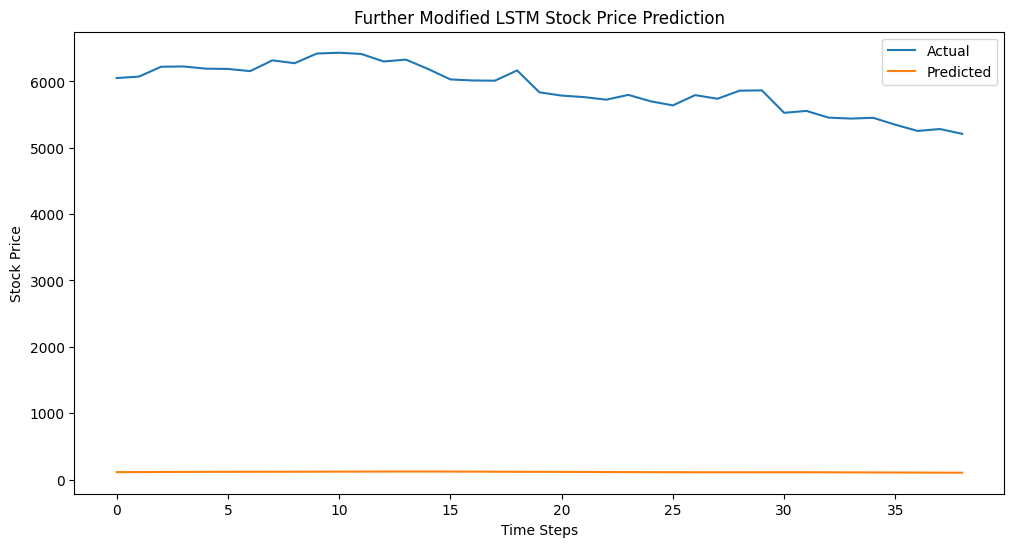

In [25]:
# Predict on the Test Data with the further modified model
y_pred_further_modified = model.predict(X_test)

# Inverse transform to get the original scale
y_pred_further_modified = scaler.inverse_transform(y_pred_further_modified.reshape(-1, 1)).reshape(-1)

# Plot the Results of the Further Modified Model
plt.figure(figsize=(12, 6))
plt.plot(y_test_original_scale, label='Actual')
plt.plot(y_pred_further_modified, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('Further Modified LSTM Stock Price Prediction')
plt.legend()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The initial LSTM model's predictions generally followed the trend of actual prices but showed noticeable deviations over time, particularly failing to capture sharper fluctuations.
*   The initial model tended to overestimate prices in later time steps.
*   Modifying the model by increasing the number of LSTM layers (to 3), increasing units per layer (to 150), increasing the dropout rate (to 0.4), and adjusting training parameters (100 epochs, batch size 128) was attempted to improve performance.
*   After the initial modifications and retraining, the model's performance was re-evaluated by plotting the actual vs. predicted prices on the test set.
*   A further modification attempt resulted in significantly less accurate predictions compared to previous attempts, indicating a degradation in performance.

### Insights or Next Steps

*   The explored modifications did not lead to improved prediction accuracy and, in a subsequent attempt, worsened the results. More extensive hyperparameter tuning, exploring different architectures, or incorporating additional features might be necessary.
*   Consider analyzing the nature of the stock price fluctuations that the model failed to capture to inform future model development or feature engineering.


**Answers to Questions:**

1.  **What is the purpose of normalizing the 'Close' prices before feeding them into the LSTM model?**
    
    Normalizing the 'Close' prices scales the data to a specific range (e.g., 0 to 1). This is important for LSTM models (and many neural networks) because:
    *   It helps the optimization algorithm (like Adam) converge faster.
    *   It prevents features with larger values from dominating the learning process.
    *   It helps the model learn the patterns in the data more effectively, especially when dealing with time series data where values can vary significantly.

2.  **What is the purpose of the Dropout layer in the LSTM model?**
    
    The Dropout layer is a regularization technique used to prevent overfitting. During training, it randomly sets a fraction of the input units to 0 at each update. This forces the network to learn more robust features that are not dependent on the presence of any single input. In LSTM models, dropout can be applied to the inputs or the recurrent connections to improve generalization.

3.  **In the plot showing actual vs predicted stock prices, what does it indicate if the predicted line closely follows the actual line?**
    
    If the predicted line closely follows the actual line in the plot, it indicates that the LSTM model is performing well and has successfully learned the underlying patterns and trends in the stock price data. A close match suggests that the model's predictions are accurate and reliable for the given time series.